CELL 1 — Imports and Configuration

In [101]:
import os
from dataclasses import dataclass
from collections import defaultdict, Counter
from typing import Dict, Tuple, List, Union, Optional, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)

# ---------------------------
# Display / plotting defaults
# ---------------------------
# Keep figures consistent across runs and export-friendly for the report.
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.dpi"] = 120

# Numeric formatting (useful for printing metric tables)
pd.set_option("display.precision", 6)
np.set_printoptions(precision=6, suppress=True)

# ---------------------------
# Lightweight logger
# ---------------------------
def log(msg: str) -> None:
    """Simple logger for consistent notebook output."""
    print(f"[INFO] {msg}")

log("Environment ready.")
log(f"NumPy seed fixed at {SEED}.")

# ---------------------------
# Global containers for Appendix A + keeping best models
# ---------------------------
appendix_rows: List[Dict[str, object]] = []
best_by_target: Dict[str, Dict[str, object]] = {}


[INFO] Environment ready.
[INFO] NumPy seed fixed at 42.


CELL 2 — Data Loading

In [102]:
def load_mackey_glass_csv(path: str, value_col: Optional[str] = None) -> np.ndarray:
    """
    Load Mackey-Glass series from a CSV file.

    Design choices (report-friendly):
    - If value_col is not provided, we automatically select the last numeric column.
    - We drop NaNs and validate finite values.
    """
    df = pd.read_csv(path)

    # Auto-pick a numeric column if not specified
    if value_col is None or value_col not in df.columns:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not num_cols:
            raise ValueError("No numeric column found in the Mackey-Glass CSV.")
        value_col = num_cols[-1]

    series = df[value_col].to_numpy(dtype=float).reshape(-1)

    # Clean + validate
    series = series[~np.isnan(series)]
    if series.size == 0:
        raise ValueError("Loaded Mackey-Glass series is empty after NaN removal.")
    if not np.all(np.isfinite(series)):
        raise ValueError("Mackey-Glass series contains non-finite values (inf/-inf).")

    return series


def load_specimens_excel(path: str, sheet_name: Union[int, str] = 0, verbose: bool = True) -> pd.DataFrame:
    """
    Load Specimens/Influenza dataset from Excel (robust to a title row + Y1/Y2 YEAR format).

    Robust steps:
    1) Read with header=None to avoid wrong header inference when the file has a title row.
    2) Detect the header row by searching for required tokens (YEAR, WEEK, TOTAL SPECIMENS).
    3) Promote that row to columns, parse numeric targets.
    4) Convert YEAR values like 'Y1' -> 1; convert WEEK to numeric.
    5) Sort chronologically by (YEAR_NUM, WEEK).
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # --- 1) Find header row index robustly ---
    required_tokens = {"YEAR", "WEEK", "TOTAL SPECIMENS"}
    header_row_idx = None

    for i in range(min(30, len(raw))):  # search first 30 rows (enough for this dataset)
        row_vals = [str(v).strip().upper() for v in raw.iloc[i].tolist() if pd.notna(v)]
        if required_tokens.issubset(set(row_vals)):
            header_row_idx = i
            break

    if header_row_idx is None:
        # Fallback: assume second row is header (common in course templates)
        header_row_idx = 1

    header = [str(x).strip() for x in raw.iloc[header_row_idx].tolist()]
    df = raw.iloc[header_row_idx + 1:].copy()
    df.columns = header
    df.columns = [str(c).strip() for c in df.columns]

    # --- 2) Validate required columns ---
    needed = ["TOTAL SPECIMENS", "TOTAL A", "TOTAL B"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}. Available: {df.columns.tolist()}")

    # --- 3) Parse numeric columns (targets + other numeric fields) ---
    # Convert everything except YEAR/WEEK safely
    for c in df.columns:
        if c not in ["YEAR", "WEEK"]:
            # handle possible string formatting; keep it simple & robust
            df[c] = (
                df[c].astype(str)
                .str.replace(",", "", regex=False)
                .str.strip()
            )
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # --- 4) YEAR/WEEK parsing ---
    if "YEAR" in df.columns:
        # YEAR may be "Y1", "Y2", ... or numeric; extract digits if needed
        year_str = df["YEAR"].astype(str).str.strip()
        year_num = year_str.str.extract(r"(\d+)", expand=False)
        df["YEAR_NUM"] = pd.to_numeric(year_num, errors="coerce")
    else:
        df["YEAR_NUM"] = np.nan

    if "WEEK" in df.columns:
        week_str = df["WEEK"].astype(str).str.strip()
        df["WEEK"] = pd.to_numeric(week_str.str.extract(r"(\d+)", expand=False), errors="coerce")

    # --- 5) Drop rows where ALL targets are missing ---
    df = df.dropna(subset=needed, how="all").reset_index(drop=True)

    # --- 6) Sort chronologically if possible (do NOT drop everything if YEAR parsing fails) ---
    if df["YEAR_NUM"].notna().any() and df["WEEK"].notna().any():
        df = df.sort_values(["YEAR_NUM", "WEEK"], na_position="last").reset_index(drop=True)

    # Final sanity
    if len(df) == 0:
        # Provide helpful debug info
        if verbose:
            print("DEBUG: header_row_idx =", header_row_idx)
            print("DEBUG: columns =", df.columns.tolist())
        raise ValueError("Specimens dataframe is empty after cleaning.")

    # Remove helper column only if you don't need it later
    # (Keeping it can be helpful for plotting by year/week)
    # df = df.drop(columns=["YEAR_NUM"])

    if verbose:
        log(f"Specimens loaded: rows={len(df)}, cols={len(df.columns)}; header_row_idx={header_row_idx}")
        log(f"Targets non-null counts: {df[needed].notna().sum().to_dict()}")

    return df


log("Data loaders defined.")


[INFO] Data loaders defined.


CELL 3 — Time Split + Metrics

In [103]:
def time_split(series: np.ndarray, train_ratio: float = 0.8) -> Tuple[np.ndarray, np.ndarray]:
    """
    Time-ordered train/test split (no shuffling) as required for time series.

    Parameters
    ----------
    series : np.ndarray
        1D time series data.
    train_ratio : float
        Fraction of samples for training (e.g., 0.8).

    Returns
    -------
    (train, test) : Tuple[np.ndarray, np.ndarray]
        Time-ordered split.
    """
    series = np.asarray(series, dtype=float).reshape(-1)

    if series.size < 10:
        raise ValueError("Series too short for meaningful train/test split.")
    if not (0.5 < train_ratio < 0.95):
        raise ValueError("train_ratio should typically be between 0.5 and 0.95.")
    if np.any(np.isnan(series)):
        # We prefer to handle NaNs before splitting for reproducibility
        series = series[~np.isnan(series)]
    if not np.all(np.isfinite(series)):
        raise ValueError("Series contains non-finite values (inf/-inf).")

    n_train = int(series.size * train_ratio)
    if n_train <= 0 or n_train >= series.size:
        raise ValueError("Invalid split: train set would be empty or equal to full series.")

    train = series[:n_train]
    test = series[n_train:]
    return train, test


def regression_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    mape_eps: float = 1e-6,
) -> Dict[str, float]:
    """
    Compute RMSE, MAE, MAPE in a report-friendly way.

    Notes (important for Influenza A/B):
    - MAPE is unstable when y_true is near zero. We compute MAPE only on points
      where |y_true| > mape_eps, and report coverage (fraction of points used).

    Returns
    -------
    Dict with:
      RMSE, MAE, MAPE, n_eval, mape_coverage
    """
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    if y_true.size != y_pred.size:
        raise ValueError("y_true and y_pred must have the same length.")
    if y_true.size == 0:
        return {"RMSE": float("nan"), "MAE": float("nan"), "MAPE": float("nan"), "n_eval": 0, "mape_coverage": 0.0}

    # Basic errors
    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))

    # MAPE with epsilon filter
    denom = np.abs(y_true)
    mask = denom > float(mape_eps)

    if np.any(mask):
        mape = float(np.mean(np.abs(err[mask] / y_true[mask])) * 100.0)
        coverage = float(np.mean(mask))  # fraction of points used in MAPE
    else:
        mape = float("nan")
        coverage = 0.0

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "n_eval": int(y_true.size),
        "mape_coverage": coverage,
    }


def mape_filtered(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = 100.0) -> float:
    """
    Optional (recommended for count series):
    Filtered MAPE computed only when y_true >= threshold.

    This is NOT a replacement for the required MAPE, but an additional diagnostic
    that you can transparently report for Influenza A/B where many weeks are near zero.
    """
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    if y_true.size != y_pred.size:
        raise ValueError("y_true and y_pred must have the same length.")

    mask = y_true >= float(threshold)
    if not np.any(mask):
        return float("nan")

    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


log("Split + metrics ready.")


[INFO] Split + metrics ready.


CELL 4 — Advanced FTS Core (FOFTS + HOFTS) with True Back-off

In [104]:
Pattern = Union[int, Tuple[int, ...]]


def mu_triangular(x: float, left: float, center: float, right: float) -> float:
    """Triangular membership function."""
    if x <= left or x >= right:
        return 0.0
    if x == center:
        return 1.0
    if x < center:
        denom = (center - left) if center != left else 1e-12
        return (x - left) / denom
    denom = (right - center) if right != center else 1e-12
    return (right - x) / denom


def mu_gaussian(x: float, center: float, sigma: float) -> float:
    """Gaussian membership function."""
    sigma = max(float(sigma), 1e-6)
    return float(np.exp(-0.5 * ((x - center) / sigma) ** 2))


@dataclass
class FTSConfig:
    n_partitions: int = 20
    order: int = 3
    mf_type: Literal["triangular", "gaussian"] = "triangular"
    margin_ratio: float = 0.05

    # Partitioning strategy:
    # - "equal": equally spaced centers across universe
    # - "quantile": centers at data quantiles (often better for skewed distributions)
    partitioning: Literal["equal", "quantile"] = "equal"

    # TRUE back-off: build FLRGs for orders 1..K and back off to smaller order when missing
    true_backoff: bool = True
    min_backoff_order: int = 1  # set to 2 if you want to avoid order-1 fallback for HOFTS

    # Fallback if no rule is found even after back-off
    fallback: Literal["persistence"] = "persistence"


class FuzzyTimeSeries:
    """
    From-scratch FTS model (FOFTS/HOFTS) required by the assignment.

    Key components for report:
    - Universe of discourse: [min - margin, max + margin]
    - Fuzzy sets: partitions over universe (equal or quantile-based centers)
    - Membership functions: triangular or gaussian
    - Fuzzification: argmax membership
    - FLRGs: frequency-aware (pattern -> Counter(outcome))
    - Defuzzification: weighted mean of consequent centers
    - HOFTS: uses last K fuzzy states; optional TRUE back-off to lower orders
    """

    def __init__(self, cfg: FTSConfig):
        self.cfg = cfg

        # Universe & partitions
        self.u_min = 0.0
        self.u_max = 1.0
        self.centers = np.array([])
        self.step = 1.0

        # Rule tables:
        # rules_by_order[k] is a dict: pattern(k) -> Counter(outcome)
        self.rules_by_order: Dict[int, Dict[Pattern, Counter]] = {}

    # -------------------- Universe & partitions --------------------
    def _build_universe_and_centers(self, data: np.ndarray) -> None:
        data = np.asarray(data, dtype=float).reshape(-1)
        dmin, dmax = float(np.min(data)), float(np.max(data))
        span = (dmax - dmin) if dmax > dmin else 1.0
        margin = self.cfg.margin_ratio * span

        self.u_min = dmin - margin
        self.u_max = dmax + margin

        if self.cfg.partitioning == "equal":
            self.centers = np.linspace(self.u_min, self.u_max, self.cfg.n_partitions)
        else:
            # Quantile-based centers allocate more sets where data is dense
            qs = np.linspace(0.0, 1.0, self.cfg.n_partitions)
            self.centers = np.quantile(data, qs)
            self.centers = np.clip(self.centers, self.u_min, self.u_max)

            # Ensure strictly increasing centers (avoid duplicates in flat regions)
            for i in range(1, len(self.centers)):
                if self.centers[i] <= self.centers[i - 1]:
                    self.centers[i] = self.centers[i - 1] + 1e-9

        # Typical step size (used for gaussian sigma)
        self.step = float(np.median(np.diff(self.centers))) if len(self.centers) > 1 else span
        self.step = max(float(self.step), 1e-9)


    # -------------------- Membership --------------------
    def membership_degree(self, x: float, i: int) -> float:
        x = float(x)

        if self.cfg.mf_type == "triangular":
            c = float(self.centers[i])
            left = self.u_min if i == 0 else float(self.centers[i - 1])
            right = self.u_max if i == self.cfg.n_partitions - 1 else float(self.centers[i + 1])
            return mu_triangular(x, left, c, right)

        if self.cfg.mf_type == "gaussian":
            c = float(self.centers[i])
            # Robust sigma floor to avoid collapse when centers are too close (quantile partitions)
            sigma_floor = 1e-6 * max((self.u_max - self.u_min), 1.0)
            sigma = max(self.step / 2.0, sigma_floor)
            return mu_gaussian(x, c, sigma)


        raise ValueError("mf_type must be 'triangular' or 'gaussian'.")

    # -------------------- Fuzzification --------------------
    def fuzzify(self, x: float) -> int:
        # Clamp into universe to avoid edge issues
        x = min(max(float(x), self.u_min), self.u_max)
        degrees = [self.membership_degree(x, i) for i in range(self.cfg.n_partitions)]
        return int(np.argmax(degrees))

    # -------------------- Fit: build FLRGs --------------------
    def fit(self, train: np.ndarray) -> "FuzzyTimeSeries":
        train = np.asarray(train, dtype=float).reshape(-1)
        if train.size <= self.cfg.order:
            raise ValueError("Training series too short for the chosen order.")

        self._build_universe_and_centers(train)
        fz = [self.fuzzify(v) for v in train]

        max_k = int(self.cfg.order)
        orders_to_build = range(1, max_k + 1) if (self.cfg.true_backoff and max_k > 1) else [max_k]

        self.rules_by_order = {}

        for k in orders_to_build:
            rules_k = defaultdict(Counter)
            for t in range(k, len(fz)):
                lhs: Pattern = fz[t - 1] if k == 1 else tuple(fz[t - k:t])
                rhs = fz[t]
                rules_k[lhs][rhs] += 1
            self.rules_by_order[k] = dict(rules_k)

        return self

    # -------------------- Defuzzification --------------------
    def _defuzzify_weighted_centers(self, rhs: Optional[Counter]) -> Optional[float]:
        if rhs is None or len(rhs) == 0:
            return None
        num = 0.0
        den = 0.0
        for idx, w in rhs.items():
            num += float(self.centers[idx]) * float(w)
            den += float(w)
        return num / den if den > 0 else None

    # -------------------- Rule lookup (with TRUE back-off) --------------------
    def _lookup(self, pattern: Pattern) -> Tuple[Optional[Counter], bool, Optional[int]]:
        """
        Returns:
        - rhs Counter if found, else None
        - is_exact: True if found at full order K
        - used_order: which order table matched
        """
        K = int(self.cfg.order)

        # First try exact K-order rule
        rhs = self.rules_by_order.get(K, {}).get(pattern, None)
        if rhs is not None:
            return rhs, True, K

        # If no true back-off, stop here
        if not self.cfg.true_backoff or K <= 1:
            return None, False, None

        # Back-off: try shorter suffix patterns in lower-order rule tables
        if isinstance(pattern, tuple):
            for k in range(K - 1, 0, -1):
                if k < int(self.cfg.min_backoff_order):
                    break
                sub = pattern[-k:]
                sub = sub[0] if k == 1 else sub
                rhs2 = self.rules_by_order.get(k, {}).get(sub, None)
                if rhs2 is not None:
                    return rhs2, False, k

        return None, False, None

    # -------------------- Predict next value (single step) --------------------
    def predict_one(self, history: List[float]) -> float:
        """
        Predict one step ahead given the recent history (length >= order).
        Designed for the interactive deliverable and internal evaluation.
        """
        K = int(self.cfg.order)
        if len(history) < K:
            raise ValueError("Not enough history for prediction.")

        pattern: Pattern = self.fuzzify(history[-1]) if K == 1 else tuple(self.fuzzify(v) for v in history[-K:])
        rhs, _, _ = self._lookup(pattern)

        yhat = self._defuzzify_weighted_centers(rhs)
        if yhat is None:
            # Fallback: persistence (last observed value)
            return float(history[-1])
        return float(yhat)

    # -------------------- Predict on test (1-step ahead, teacher forcing) --------------------
    def predict_test(self, test: np.ndarray, initial_history: np.ndarray) -> Tuple[np.ndarray, Dict[str, float]]:
        """
        1-step ahead prediction using teacher forcing.
        Returns predictions and diagnostics useful for report discussion.
        """
        test = np.asarray(test, dtype=float).reshape(-1)
        history = list(map(float, np.asarray(initial_history, dtype=float).reshape(-1)))

        preds = np.zeros(len(test), dtype=float)

        exact_hits = 0
        any_hits = 0
        fallbacks = 0
        backoffs = 0

        K = int(self.cfg.order)

        for t in range(len(test)):
            pattern: Pattern = self.fuzzify(history[-1]) if K == 1 else tuple(self.fuzzify(v) for v in history[-K:])
            rhs, is_exact, used_k = self._lookup(pattern)

            if is_exact:
                exact_hits += 1
            if rhs is not None:
                any_hits += 1
                if not is_exact:
                    backoffs += 1

            yhat = self._defuzzify_weighted_centers(rhs)
            if yhat is None:
                fallbacks += 1
                yhat = history[-1]

            preds[t] = float(yhat)
            history.append(float(test[t]))  # teacher forcing

        diag = {
            "hit_rate_exact": exact_hits / len(test),
            "hit_rate_any": any_hits / len(test),
            "fallback_rate": fallbacks / len(test),
            "backoff_rate": backoffs / len(test),
        }
        return preds, diag


log("Advanced FTS model ready.")


[INFO] Advanced FTS model ready.


CELL 5 — Visualization + FLRG export (Appendix)

In [105]:
from pathlib import Path

def _maybe_savefig(save_path: Optional[str]) -> None:
    """Save the current figure if save_path is provided."""
    if save_path:
        Path(os.path.dirname(save_path) or ".").mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")
        log(f"Saved figure -> {save_path}")


def plot_forecast(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    save_path: Optional[str] = None
) -> None:
    """
    Plot actual vs predicted over the test segment.
    Useful for the required visualization deliverable.
    """
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    plt.figure(figsize=(14, 5))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, linestyle="--", label="Predicted")
    plt.title(title)
    plt.xlabel("Time index (test)")
    plt.ylabel("Value")
    plt.legend()
    _maybe_savefig(save_path)
    plt.show()


def plot_metric_by_partitions(
    results_df: pd.DataFrame,
    metric: str = "RMSE",
    title: str = "",
    save_path: Optional[str] = None
) -> None:
    """
    Plot a chosen metric (RMSE/MAE/MAPE) vs partitions for each order.
    This supports the assignment requirement: \"error metrics across parameter space\".
    """
    if metric not in results_df.columns:
        raise ValueError(f"Metric '{metric}' not found. Available: {results_df.columns.tolist()}")

    plt.figure(figsize=(12, 5))
    for o in sorted(results_df["order"].unique()):
        sub = results_df[results_df["order"] == o].sort_values("partitions")
        plt.plot(sub["partitions"], sub[metric], marker="o", label=f"order={o}")

    plt.title(title or f"{metric} across parameter space")
    plt.xlabel("Number of partitions")
    plt.ylabel(metric)
    plt.legend()
    _maybe_savefig(save_path)
    plt.show()


def plot_membership_functions(
    model: "FuzzyTimeSeries",
    n_points: int = 500,
    save_path: Optional[str] = None
) -> None:
    """
    Plot all membership functions (Appendix requirement: membership function plots).
    """
    xs = np.linspace(model.u_min, model.u_max, n_points)
    plt.figure(figsize=(14, 5))

    for i in range(model.cfg.n_partitions):
        ys = [model.membership_degree(float(x), i) for x in xs]
        plt.plot(xs, ys, label=f"A{i+1}")

    plt.title(f"Membership Functions — {model.cfg.mf_type}, partitions={model.cfg.n_partitions}")
    plt.xlabel("Universe of discourse")
    plt.ylabel("Membership degree")
    plt.legend(ncol=5, fontsize=8)
    _maybe_savefig(save_path)
    plt.show()


def export_flrgs(
    model: "FuzzyTimeSeries",
    path: str,
    order: Optional[int] = None
) -> None:
    """
    Export final FLRGs to a text file (Appendix B).

    Compatible with:
    - model.rules (single-order table)
    - model.rules_by_order[k] (true back-off tables)

    Parameters
    ----------
    model : FuzzyTimeSeries
        Trained model.
    path : str
        Output path (e.g., '/content/mg_best_flrgs_order3.txt').
    order : Optional[int]
        If model has rules_by_order, choose which order to export.
        If None, exports model.cfg.order by default.
    """
    def lhs_to_str(p: Pattern) -> str:
        if isinstance(p, tuple):
            return ",".join([f"A{i+1}" for i in p])
        return f"A{p+1}"

    # Decide which rule table to export
    rules_table = None

    if hasattr(model, "rules_by_order") and isinstance(getattr(model, "rules_by_order"), dict) and model.rules_by_order:
        k = int(order) if order is not None else int(model.cfg.order)
        if k not in model.rules_by_order:
            available = sorted(model.rules_by_order.keys())
            raise ValueError(f"Requested order={k} not available. Available orders: {available}")
        rules_table = model.rules_by_order[k]
    else:
        # fallback for single-table models
        if not hasattr(model, "rules") or model.rules is None:
            raise ValueError("Model has no rules to export.")
        rules_table = model.rules

    # Write FLRGs
    lines = []
    for lhs, rhs in sorted(rules_table.items(), key=lambda kv: str(kv[0])):
        rhs_str = " ".join([f"A{i+1}({c})" for i, c in rhs.most_common()])
        lines.append(f"{lhs_to_str(lhs)} -> {rhs_str}")

    Path(os.path.dirname(path) or ".").mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    log(f"Exported FLRGs -> {path} (rules={len(rules_table)})")


def export_all_orders_flrgs(model: "FuzzyTimeSeries", out_dir: str, prefix: str) -> None:
    """
    If true back-off is enabled and multiple order tables exist,
    export FLRGs for each order separately. Useful for Appendix B.
    """
    if not (hasattr(model, "rules_by_order") and model.rules_by_order):
        raise ValueError("Model does not contain rules_by_order. Enable true_backoff and refit.")

    Path(out_dir).mkdir(parents=True, exist_ok=True)
    for k in sorted(model.rules_by_order.keys()):
        export_flrgs(model, os.path.join(out_dir, f"{prefix}_flrgs_order{k}.txt"), order=k)


log("Plot + export utilities ready.")


[INFO] Plot + export utilities ready.


CELL 6 — Grid Search over parameter space (order × partitions)

In [106]:
def _count_rules(model: "FuzzyTimeSeries", order: int) -> int:
    """Return the number of rules for the requested order (robust to model type)."""
    if hasattr(model, "rules_by_order") and isinstance(model.rules_by_order, dict) and model.rules_by_order:
        return len(model.rules_by_order.get(order, {}))
    # fallback for single-table models
    if hasattr(model, "rules") and model.rules is not None:
        return len(model.rules)
    return 0


def _apply_transform(series: np.ndarray, transform: str) -> np.ndarray:
    """Apply optional transform to stabilize variance (log1p for skewed count data)."""
    series = np.asarray(series, dtype=float).reshape(-1)
    if transform == "none":
        return series
    if transform == "log1p":
        return np.log1p(np.maximum(series, 0.0))
    raise ValueError("transform must be one of: 'none', 'log1p'")


def _inverse_transform(arr: np.ndarray, transform: str) -> np.ndarray:
    """Invert transform back to original scale for evaluation/plots."""
    arr = np.asarray(arr, dtype=float).reshape(-1)
    if transform == "none":
        return arr
    if transform == "log1p":
        return np.expm1(arr)
    raise ValueError("transform must be one of: 'none', 'log1p'")


def grid_search(
    series: np.ndarray,
    orders: List[int],
    partitions: List[int],
    mf_type: str = "triangular",
    margin_ratio: float = 0.05,
    partitioning: str = "equal",        # "equal" or "quantile"
    true_backoff: bool = True,
    min_backoff_order: int = 1,
    transform: str = "none",            # "none" or "log1p"
    clamp_nonneg: bool = False,
    select_by: str = "RMSE",            # "RMSE" or "MAE" or "MAPE"
) -> Tuple[pd.DataFrame, Dict]:
    """
    Systematic experiments over (order, partitions) with advanced options.

    Returns
    -------
    results_df : pd.DataFrame
        One row per configuration: metrics + diagnostics + rule counts.
    best : Dict
        Best configuration by `select_by`, includes model and predictions.
    """
    series = np.asarray(series, dtype=float).reshape(-1)
    series_t = _apply_transform(series, transform=transform)

    train_t, test_t = time_split(series_t, train_ratio=0.8)

    rows = []
    best = None

    for o in orders:
        for p in partitions:
            cfg = FTSConfig(
                n_partitions=int(p),
                order=int(o),
                mf_type=mf_type,
                margin_ratio=float(margin_ratio),
                partitioning=partitioning,
                true_backoff=bool(true_backoff),
                min_backoff_order=int(min_backoff_order),
                fallback="persistence",
            )

            model = FuzzyTimeSeries(cfg).fit(train_t)

            # Teacher forcing evaluation
            pred_t, diag = model.predict_test(test_t, initial_history=train_t[-o:])

            # Invert transform for metric computation on original scale
            y_true = _inverse_transform(test_t, transform=transform)
            y_pred = _inverse_transform(pred_t, transform=transform)

            # Post-processing for count data
            if clamp_nonneg:
                y_pred = np.maximum(y_pred, 0.0)

            m = regression_metrics(y_true, y_pred)

            row = {
                # configuration
                "order": int(o),
                "partitions": int(p),
                "mf_type": mf_type,
                "partitioning": partitioning,
                "true_backoff": bool(true_backoff),
                "transform": transform,
                "clamp_nonneg": bool(clamp_nonneg),

                # metrics
                "RMSE": m["RMSE"],
                "MAE": m["MAE"],
                "MAPE": m["MAPE"],
                "mape_coverage": m.get("mape_coverage", np.nan),
                "n_eval": m.get("n_eval", len(y_true)),

                # rule stats (order-specific)
                "n_rules_orderK": _count_rules(model, order=int(o)),

                # diagnostics from prediction
                **diag,
            }
            rows.append(row)

            # Select best configuration
            if select_by not in row:
                raise ValueError(f"select_by={select_by} not available in row keys.")
            if best is None or row[select_by] < best[select_by]:
                best = {
                    **row,
                    "model": model,
                    "train": _inverse_transform(train_t, transform=transform),
                    "test": y_true,
                    "pred": y_pred,
                }

    results_df = pd.DataFrame(rows).sort_values([select_by, "MAE"], ascending=True).reset_index(drop=True)
    return results_df, best


log("Grid search ready.")


[INFO] Grid search ready.


CELL 7 — Dataset 1: Mackey-Glass Experiments

[INFO] Mackey-Glass loaded: n=1000


,order,partitions,mf_type,partitioning,true_backoff,transform,clamp_nonneg,RMSE,MAE,MAPE,mape_coverage,n_eval,n_rules_orderK,hit_rate_exact,hit_rate_any,fallback_rate,backoff_rate
0,3,30,triangular,equal,True,none,False,0.034076,0.025283,4.074953,1.0,200,232,0.880,0.970,0.030,0.090
1,4,30,triangular,equal,True,none,False,0.034590,0.025322,4.023289,1.0,200,375,0.750,0.970,0.030,0.220
2,2,30,triangular,equal,True,none,False,0.037252,0.029602,4.736811,1.0,200,113,0.950,0.970,0.030,0.020
3,4,20,triangular,equal,True,none,False,0.040710,0.031840,5.222645,1.0,200,221,0.860,0.965,0.035,0.105
4,3,20,triangular,equal,True,none,False,0.042213,0.033970,5.544327,1.0,200,130,0.930,0.965,0.035,0.035
5,2,20,triangular,equal,True,none,False,0.042807,0.034147,5.667625,1.0,200,60,0.950,0.965,0.035,0.015
6,4,15,triangular,equal,True,none,False,0.046900,0.037140,6.258349,1.0,200,147,0.910,0.955,0.045,0.045
7,1,30,triangular,equal,True,none,False,0.050110,0.040302,6.766052,1.0,200,28,0.970,0.970,0.030,0.000
8,3,15,triangular,equal,True,none,False,0.050801,0.040842,6.757802,1.0,200,81,0.945,0.955,0.045,0.010
9,1,20,triangular,equal,True,none,False,0.053125,0.041923,7.350686,1.0,200,18,0.965,0.965,0.035,0.000


Best MG configuration:
{'order': 3, 'partitions': 30, 'mf_type': 'triangular', 'partitioning': 'equal', 'true_backoff': True, 'transform': 'none', 'clamp_nonneg': False, 'RMSE': 0.03407609522792668, 'MAE': 0.025283160445775322, 'MAPE': 4.074953228206175, 'mape_coverage': 1.0, 'n_rules_orderK': 232, 'hit_rate_exact': 0.88, 'hit_rate_any': 0.97, 'fallback_rate': 0.03, 'backoff_rate': 0.09}
[INFO] Saved figure -> /content/outputs_mg/mg_best_forecast.png


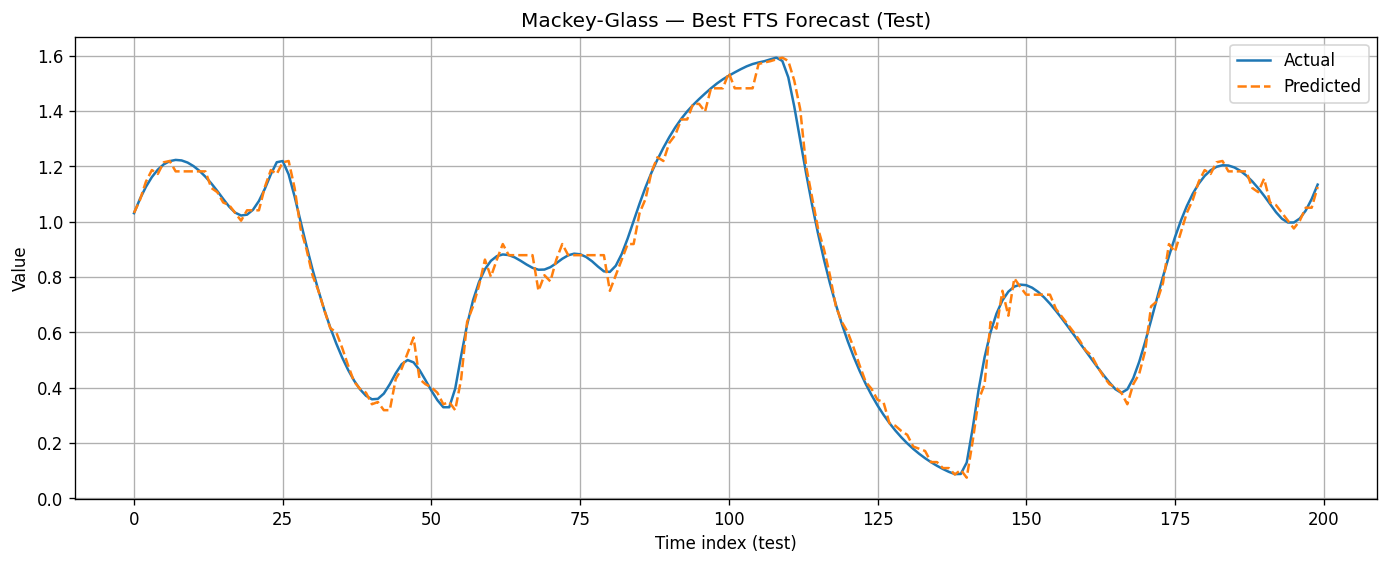

[INFO] Saved figure -> /content/outputs_mg/mg_rmse_across_params.png


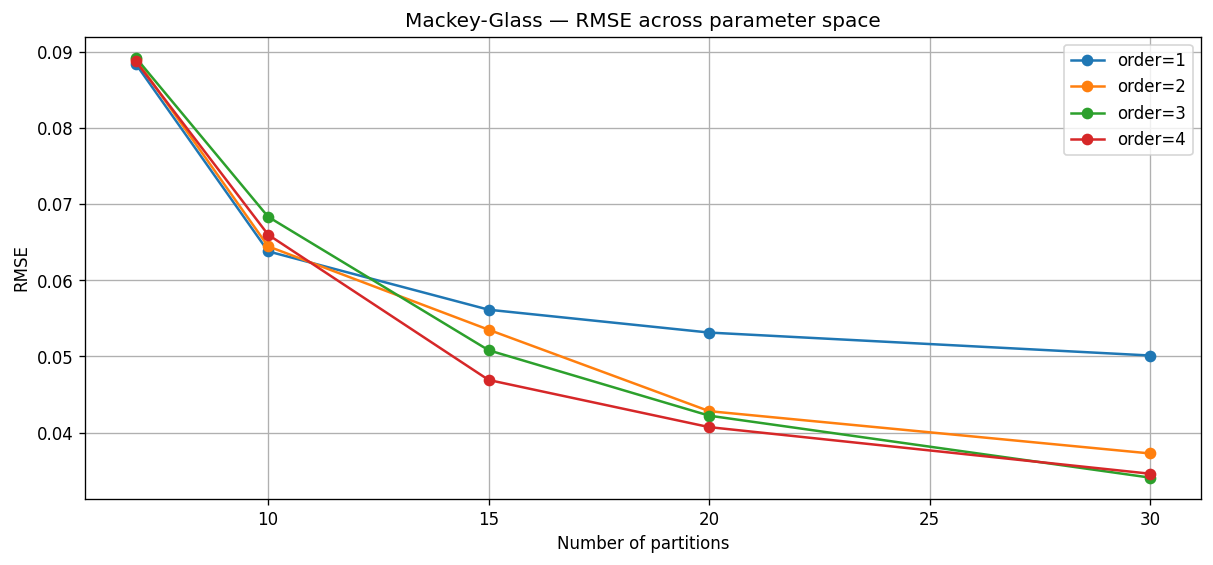

[INFO] Saved figure -> /content/outputs_mg/mg_membership_functions.png


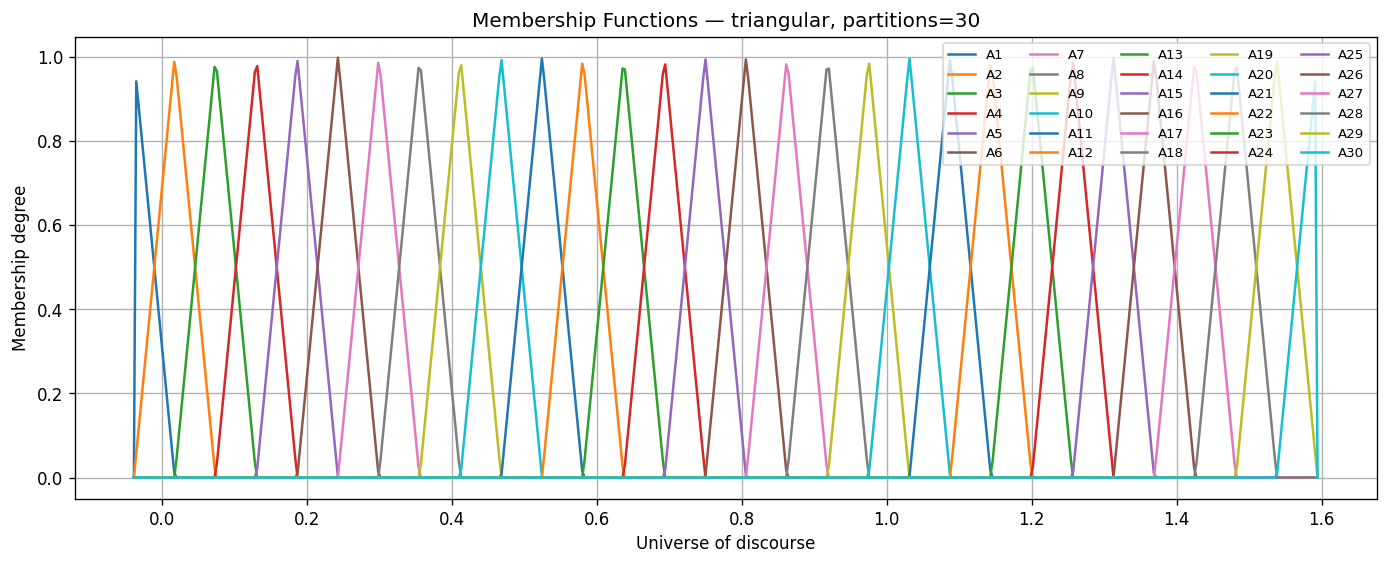

Best MG configuration:
{'order': 3, 'partitions': 30, 'mf_type': 'triangular', 'partitioning': 'equal', 'true_backoff': True, 'transform': 'none', 'clamp_nonneg': False, 'RMSE': 0.03407609522792668, 'MAE': 0.025283160445775322, 'MAPE': 4.074953228206175, 'mape_coverage': 1.0, 'n_rules_orderK': 232, 'hit_rate_exact': 0.88, 'hit_rate_any': 0.97, 'fallback_rate': 0.03, 'backoff_rate': 0.09}
[INFO] Exported FLRGs -> /content/outputs_mg/mg_best_flrgs_order3.txt (rules=232)
[INFO] Exported FLRGs -> /content/outputs_mg/MG_best_flrgs_order1.txt (rules=28)
[INFO] Exported FLRGs -> /content/outputs_mg/MG_best_flrgs_order2.txt (rules=113)
[INFO] Exported FLRGs -> /content/outputs_mg/MG_best_flrgs_order3.txt (rules=232)
[INFO] Exported FLRGs -> /content/outputs_mg/MG_best_flrgs_order1.txt (rules=28)
[INFO] Exported FLRGs -> /content/outputs_mg/MG_best_flrgs_order2.txt (rules=113)
[INFO] Exported FLRGs -> /content/outputs_mg/MG_best_flrgs_order3.txt (rules=232)
[INFO] Saved outputs to: /content/out

In [107]:
# ---------------------------
# Paths (Colab)
# ---------------------------
mg_path = "/content/mackey_glass.csv"
out_dir = "/content/outputs_mg"
os.makedirs(out_dir, exist_ok=True)

# ---------------------------
# Load dataset
# ---------------------------
mg_series = load_mackey_glass_csv(mg_path)
log(f"Mackey-Glass loaded: n={len(mg_series)}")

# ---------------------------
# Grid search (FOFTS vs HOFTS)
# ---------------------------
mg_results, mg_best = grid_search(
    mg_series,
    orders=[1, 2, 3, 4],
    partitions=[7, 10, 15, 20, 30],
    mf_type="triangular",
    partitioning="equal",
    true_backoff=True,
    transform="none",
    clamp_nonneg=False,
    select_by="RMSE",
)

# Show top results
display(mg_results.head(10))

# Print best configuration summary (report-friendly)
best_keys = [
    "order", "partitions", "mf_type", "partitioning",
    "true_backoff", "transform", "clamp_nonneg",
    "RMSE", "MAE", "MAPE", "mape_coverage",
    "n_rules_orderK", "hit_rate_exact", "hit_rate_any",
    "fallback_rate", "backoff_rate",
]
print("Best MG configuration:")
print({k: mg_best[k] for k in best_keys if k in mg_best})

# ---------------------------
# Plots (save for report)
# ---------------------------
plot_forecast(
    mg_best["test"], mg_best["pred"],
    title="Mackey-Glass — Best FTS Forecast (Test)",
    save_path=os.path.join(out_dir, "mg_best_forecast.png")
)

plot_metric_by_partitions(
    mg_results,
    metric="RMSE",
    title="Mackey-Glass — RMSE across parameter space",
    save_path=os.path.join(out_dir, "mg_rmse_across_params.png")
)

plot_membership_functions(
    mg_best["model"],
    save_path=os.path.join(out_dir, "mg_membership_functions.png")
)

print("Best MG configuration:")
print({k: mg_best[k] for k in best_keys if k in mg_best})

# ---------------------------
# Appendix A row (Mackey-Glass)
# ---------------------------
appendix_rows.append({
    "dataset": "Mackey-Glass",
    "target": "series",
    "order": mg_best["order"],
    "partitions": mg_best["partitions"],
    "mf_type": mg_best["mf_type"],
    "partitioning": mg_best["partitioning"],
    "transform": mg_best["transform"],
    "true_backoff": mg_best["true_backoff"],
    "RMSE": mg_best["RMSE"],
    "MAE": mg_best["MAE"],
    "MAPE": mg_best["MAPE"],
    "mape_coverage": mg_best["mape_coverage"],
    "n_rules_orderK": mg_best["n_rules_orderK"],
})


# ---------------------------
# Export FLRGs (Appendix B)
# ---------------------------
# Export the FLRGs for the best order (K) table.
export_flrgs(
    mg_best["model"],
    path=os.path.join(out_dir, f"mg_best_flrgs_order{mg_best['order']}.txt"),
    order=int(mg_best["order"])
)


# Export FLRGs for all orders (1..K) for completeness (Appendix B)
export_all_orders_flrgs(mg_best["model"], out_dir, prefix="MG_best")

export_all_orders_flrgs(mg_best["model"], out_dir, prefix="MG_best")

# ---------------------------
# Save grid results (reproducibility)
# ---------------------------
mg_results.to_csv(os.path.join(out_dir, "mg_grid_results.csv"), index=False)
log(f"Saved outputs to: {out_dir}")


CELL 8 — Dataset 2: Specimens / Influenza A/B

[INFO] Specimens loaded: rows=238, cols=9; header_row_idx=1
[INFO] Targets non-null counts: {'TOTAL SPECIMENS': 238, 'TOTAL A': 238, 'TOTAL B': 238}
[INFO] Specimens dataframe loaded: shape=(238, 9)
[INFO] Running target: TOTAL SPECIMENS (n=238)

Target: TOTAL SPECIMENS
Best configuration:
{'order': 1, 'partitions': 15, 'mf_type': 'triangular', 'partitioning': 'equal', 'true_backoff': True, 'transform': 'none', 'clamp_nonneg': True, 'RMSE': 10617.99922065133, 'MAE': 8352.65706833214, 'MAPE': 10.130923216007687, 'mape_coverage': 1.0, 'n_rules_orderK': 13, 'hit_rate_exact': 1.0, 'hit_rate_any': 1.0, 'fallback_rate': 0.0, 'backoff_rate': 0.0}
[INFO] Saved figure -> /content/outputs_influenza/TOTAL_SPECIMENS_best_forecast.png


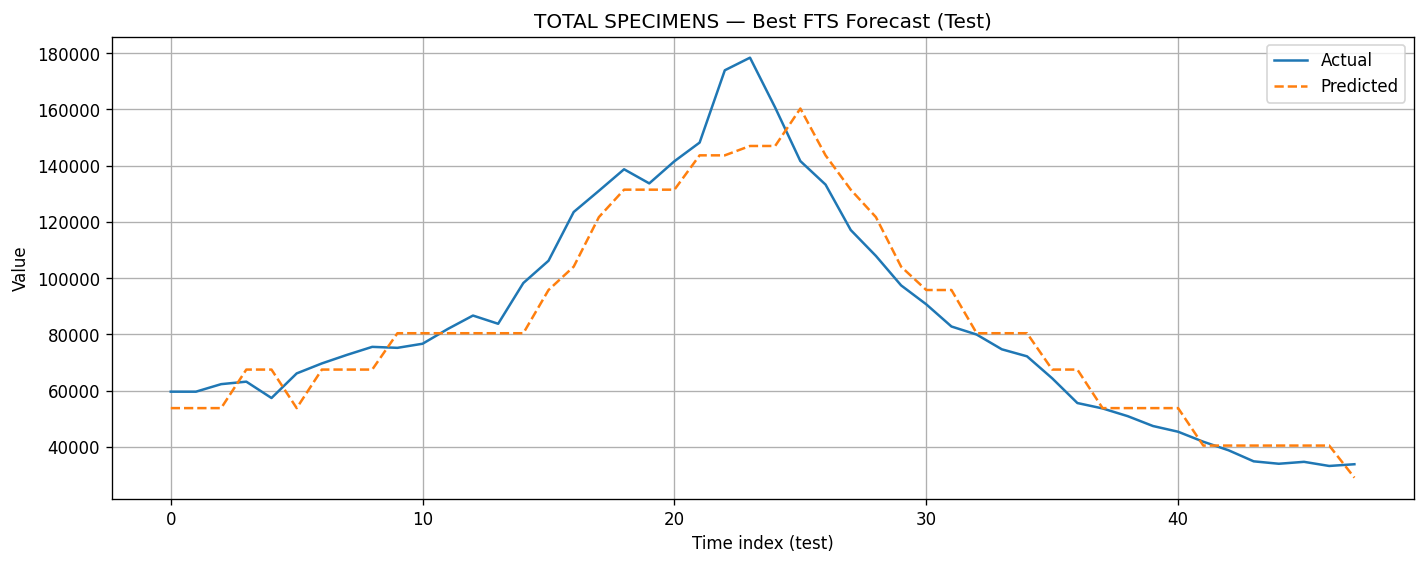

[INFO] Saved figure -> /content/outputs_influenza/TOTAL_SPECIMENS_rmse_across_params.png


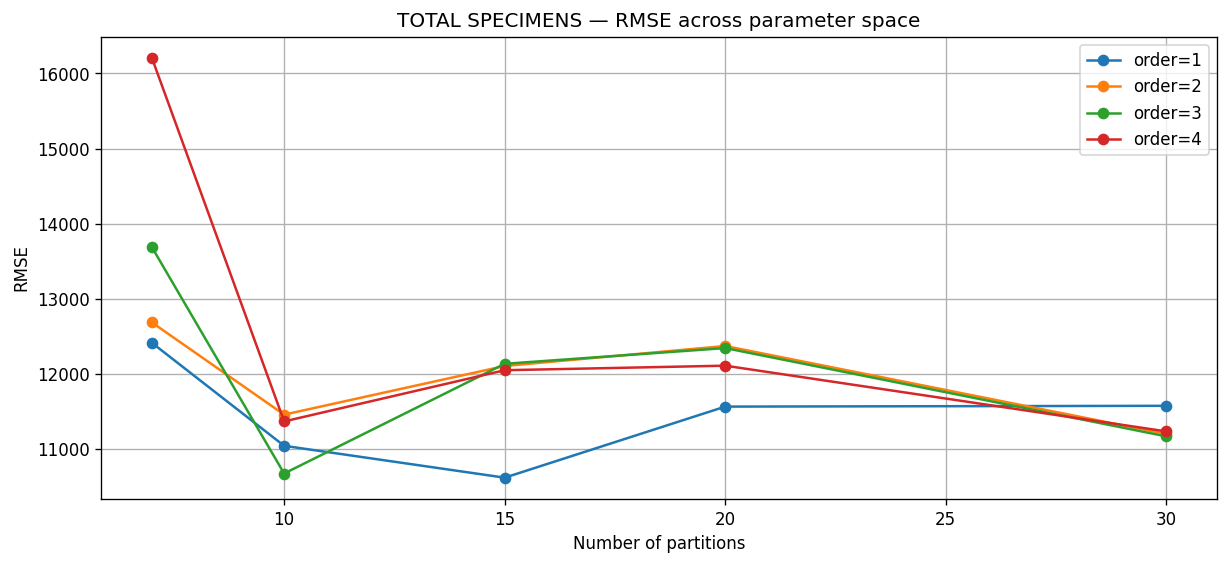

[INFO] Saved figure -> /content/outputs_influenza/TOTAL_SPECIMENS_membership_functions.png


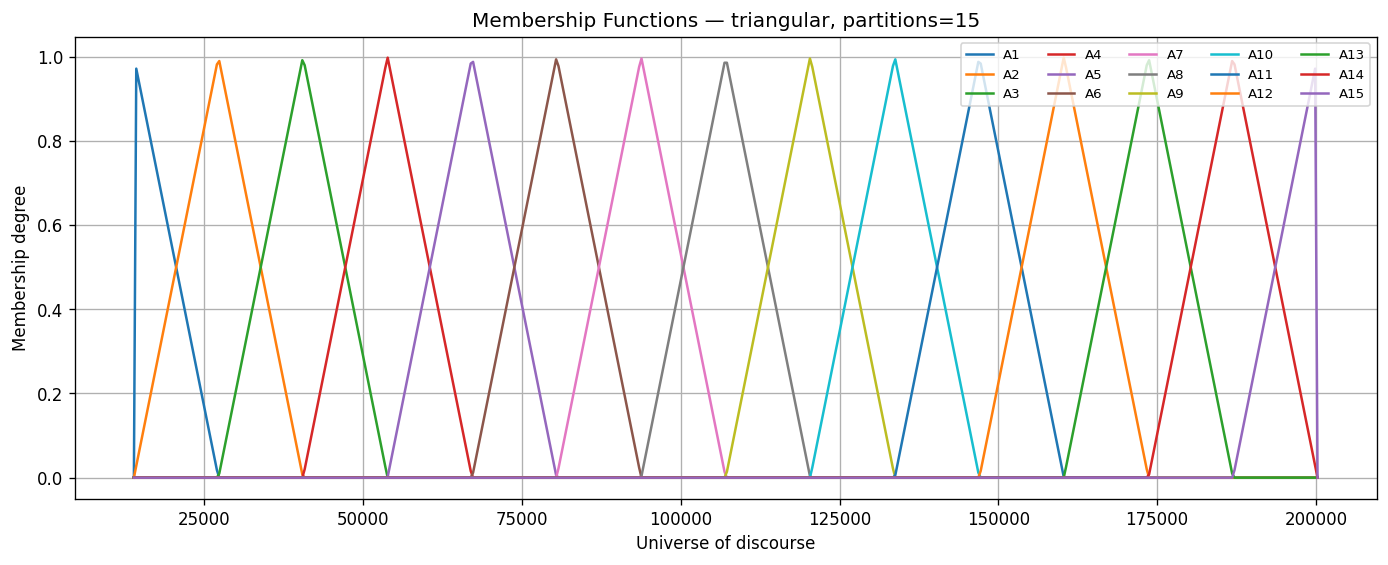

[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_SPECIMENS_best_flrgs_order1.txt (rules=13)
[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_SPECIMENS_flrgs_order1.txt (rules=13)
[INFO] Running target: TOTAL A (n=238)

Target: TOTAL A
Best configuration:
{'order': 3, 'partitions': 30, 'mf_type': 'triangular', 'partitioning': 'equal', 'true_backoff': True, 'transform': 'log1p', 'clamp_nonneg': True, 'RMSE': 3700.4063119736857, 'MAE': 1699.9976598970904, 'MAPE': 25.61858405140785, 'mape_coverage': 1.0, 'n_rules_orderK': 124, 'hit_rate_exact': 0.6458333333333334, 'hit_rate_any': 1.0, 'fallback_rate': 0.0, 'backoff_rate': 0.3541666666666667}
MAPE_filtered(y>=100): 25.6186
[INFO] Saved figure -> /content/outputs_influenza/TOTAL_A_best_forecast.png


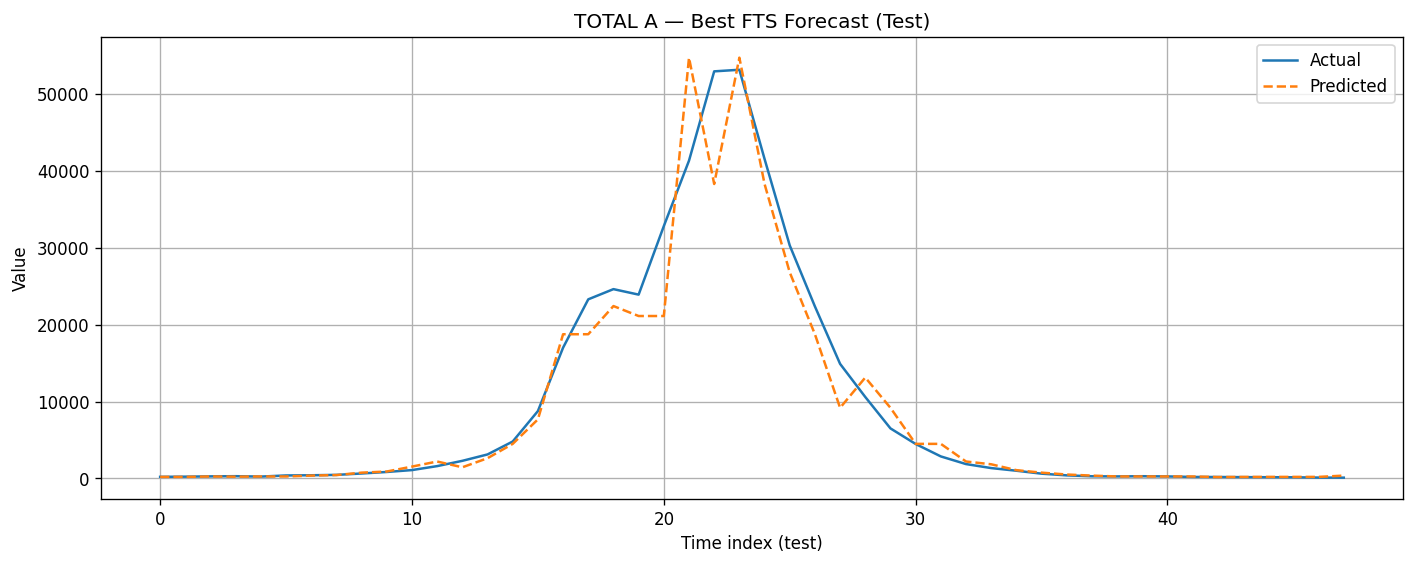

[INFO] Saved figure -> /content/outputs_influenza/TOTAL_A_rmse_across_params.png


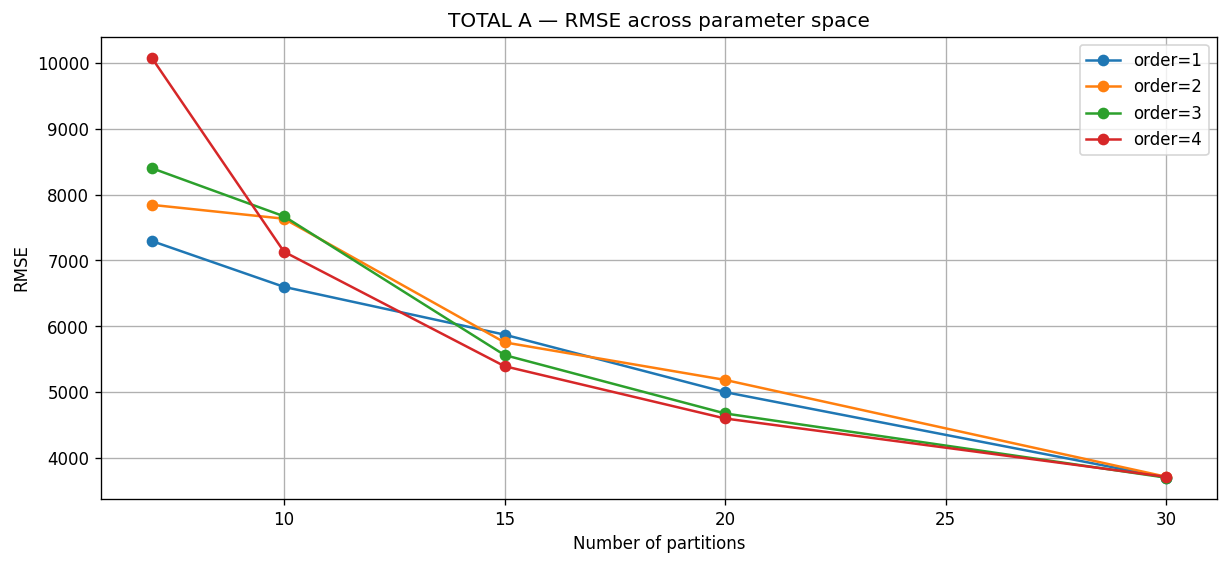

[INFO] Saved figure -> /content/outputs_influenza/TOTAL_A_membership_functions.png


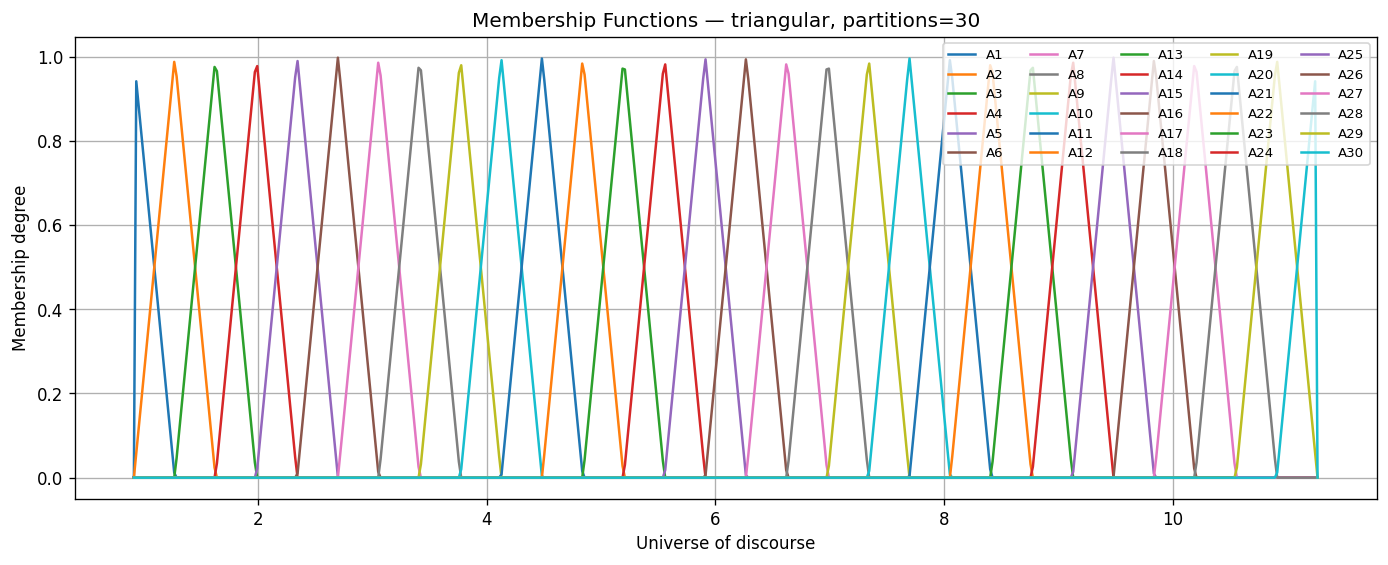

[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_A_best_flrgs_order3.txt (rules=124)
[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_A_flrgs_order1.txt (rules=27)
[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_A_flrgs_order2.txt (rules=79)
[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_A_flrgs_order3.txt (rules=124)
[INFO] Running target: TOTAL B (n=238)

Target: TOTAL B
Best configuration:
{'order': 1, 'partitions': 15, 'mf_type': 'triangular', 'partitioning': 'equal', 'true_backoff': True, 'transform': 'log1p', 'clamp_nonneg': True, 'RMSE': 332.4181241174434, 'MAE': 214.61497671864947, 'MAPE': 28.377110325424308, 'mape_coverage': 1.0, 'n_rules_orderK': 13, 'hit_rate_exact': 1.0, 'hit_rate_any': 1.0, 'fallback_rate': 0.0, 'backoff_rate': 0.0}
MAPE_filtered(y>=100): 28.8118
[INFO] Saved figure -> /content/outputs_influenza/TOTAL_B_best_forecast.png


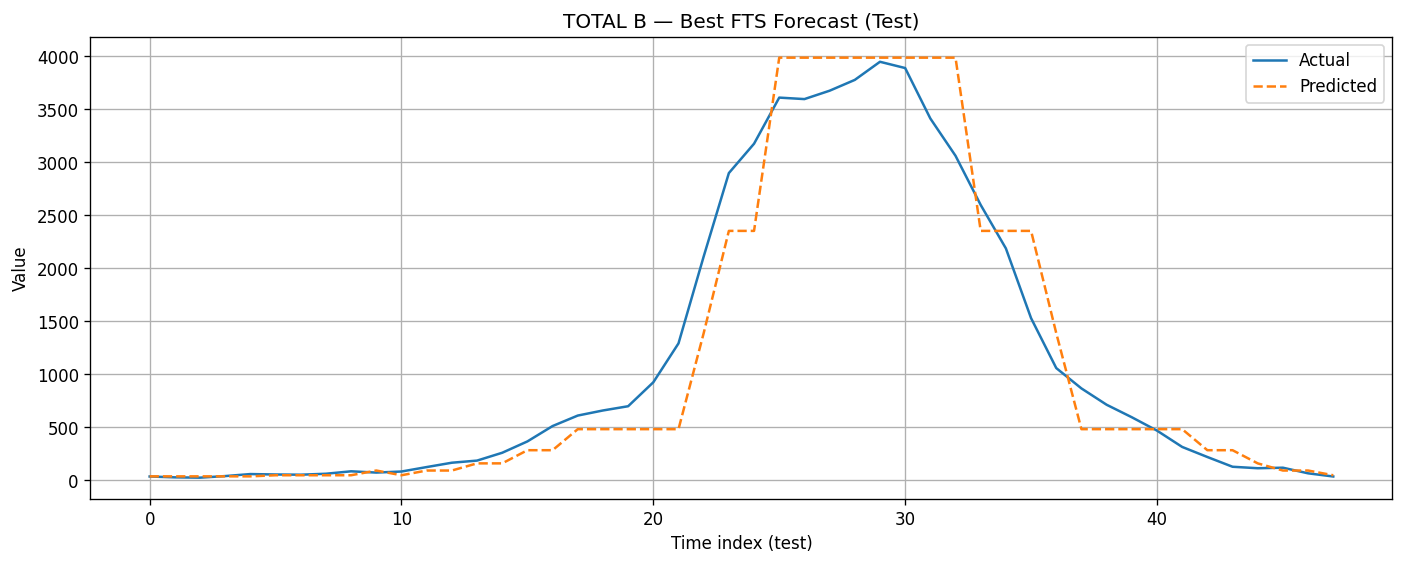

[INFO] Saved figure -> /content/outputs_influenza/TOTAL_B_rmse_across_params.png


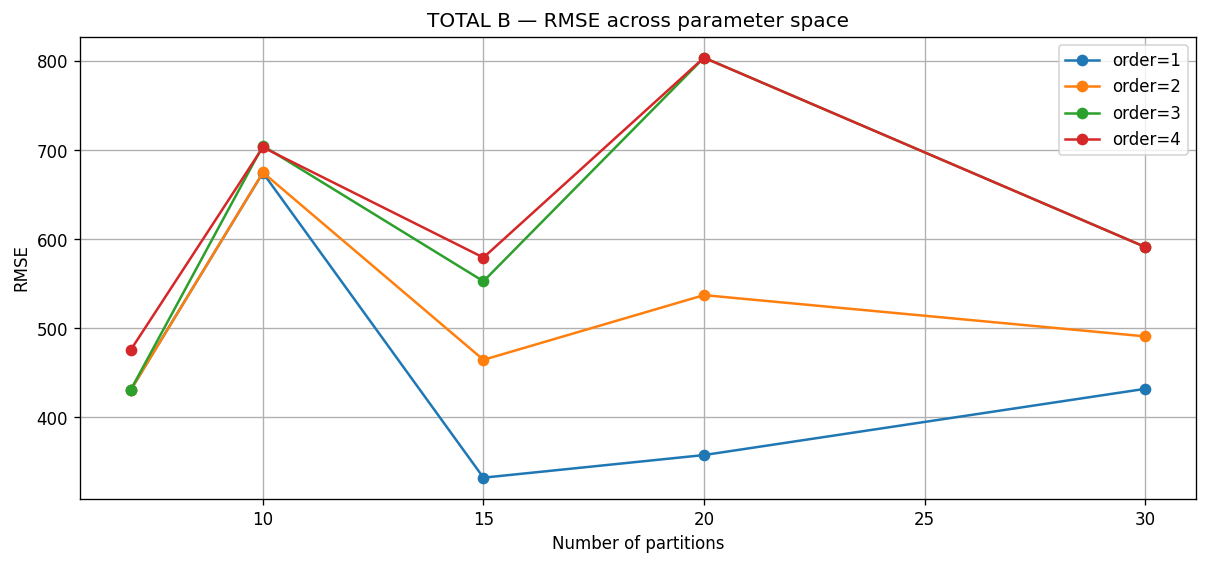

[INFO] Saved figure -> /content/outputs_influenza/TOTAL_B_membership_functions.png


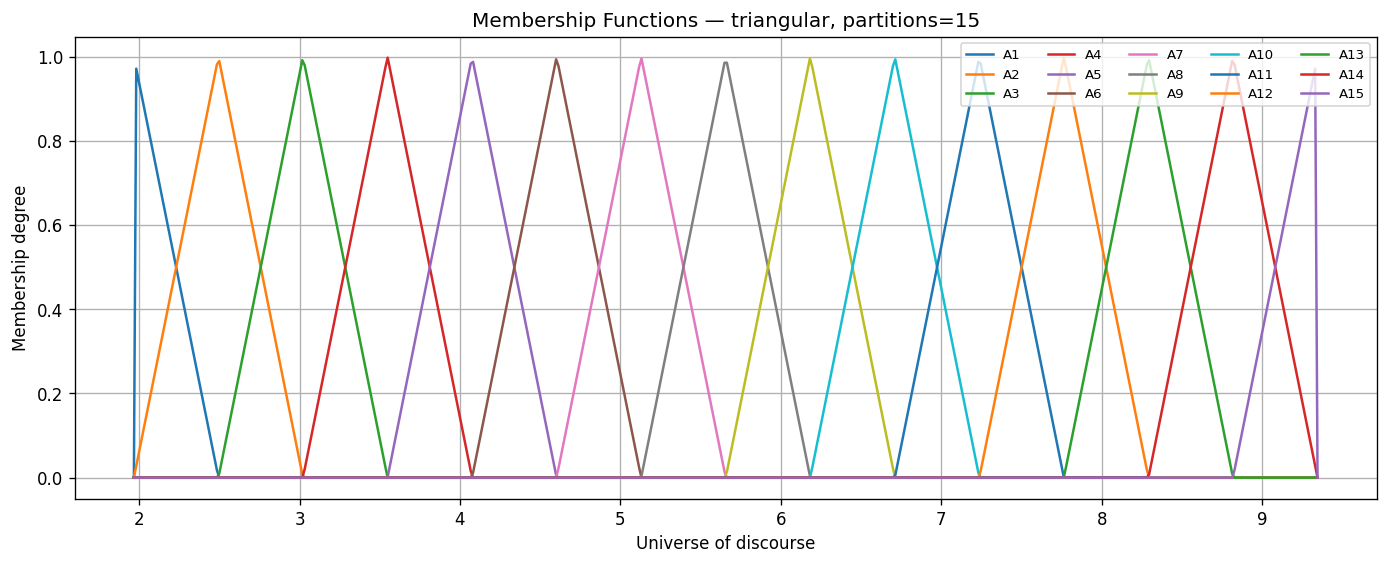

[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_B_best_flrgs_order1.txt (rules=13)
[INFO] Exported FLRGs -> /content/outputs_influenza/TOTAL_B_flrgs_order1.txt (rules=13)
[INFO] Saved Influenza outputs to: /content/outputs_influenza
[INFO] Saved Appendix A (ALL datasets) -> /content/appendix_A_best_configs_ALL.csv


In [108]:
spec_path = "/content/Specimens-Train.xlsx"
out_dir = "/content/outputs_influenza"
os.makedirs(out_dir, exist_ok=True)

# ---------------------------
# Load dataset
# ---------------------------
spec_df = load_specimens_excel(spec_path, verbose=True)
log(f"Specimens dataframe loaded: shape={spec_df.shape}")

targets = ["TOTAL SPECIMENS", "TOTAL A", "TOTAL B"]

# Shared grid parameters
ORDERS = [1, 2, 3, 4]
PARTS  = [7, 10, 15, 20, 30]

for col in targets:
    series = spec_df[col].to_numpy(dtype=float).reshape(-1)
    log(f"Running target: {col} (n={len(series)})")

    # ---------------------------
    # Recommended settings by target type
    # ---------------------------
    if col == "TOTAL SPECIMENS":
        transform = "none"
        clamp_nonneg = True
        partitioning_candidates = ["equal"]
        threshold_for_mape = None
    else:
        transform = "log1p"
        clamp_nonneg = True
        partitioning_candidates = ["equal", "quantile"]
        threshold_for_mape = 100.0

    best_overall = None
    best_results_df = None

    # ---------------------------
    # Grid search across partitioning candidates
    # ---------------------------
    for part_method in partitioning_candidates:
        res, best = grid_search(
            series,
            orders=ORDERS,
            partitions=PARTS,
            mf_type="triangular",
            margin_ratio=0.05,
            partitioning=part_method,
            true_backoff=True,
            min_backoff_order=1,
            transform=transform,
            clamp_nonneg=clamp_nonneg,
            select_by="RMSE",
        )

        if (best_overall is None) or (best["RMSE"] < best_overall["RMSE"]):
            best_overall = best
            best_results_df = res

    # ---------------------------
    # Persist best per target for interactive demo (CELL 9)
    # ---------------------------
    best_by_target[col] = {
        "best": best_overall,
        "results": best_results_df,
    }

    # ---------------------------
    # Appendix A row (Influenza)
    # ---------------------------
    appendix_rows.append({
        "dataset": "Influenza",
        "target": col,
        "order": best_overall["order"],
        "partitions": best_overall["partitions"],
        "mf_type": best_overall["mf_type"],
        "partitioning": best_overall["partitioning"],
        "transform": best_overall["transform"],
        "true_backoff": best_overall["true_backoff"],
        "RMSE": best_overall["RMSE"],
        "MAE": best_overall["MAE"],
        "MAPE": best_overall["MAPE"],
        "mape_coverage": best_overall["mape_coverage"],
        "n_rules_orderK": best_overall["n_rules_orderK"],
    })

    # ---------------------------
    # Console summary
    # ---------------------------
    summary_keys = [
        "order", "partitions", "mf_type", "partitioning",
        "true_backoff", "transform", "clamp_nonneg",
        "RMSE", "MAE", "MAPE", "mape_coverage",
        "n_rules_orderK", "hit_rate_exact", "hit_rate_any",
        "fallback_rate", "backoff_rate",
    ]
    print(f"\nTarget: {col}")
    print("Best configuration:")
    print({k: best_overall[k] for k in summary_keys if k in best_overall})

    if threshold_for_mape is not None:
        mf = mape_filtered(best_overall["test"], best_overall["pred"], threshold=threshold_for_mape)
        print(f"MAPE_filtered(y>={threshold_for_mape:.0f}): {mf:.4f}")

    # ---------------------------
    # Save plots + exports
    # ---------------------------
    safe_name = col.replace(" ", "_")

    plot_forecast(
        best_overall["test"], best_overall["pred"],
        title=f"{col} — Best FTS Forecast (Test)",
        save_path=os.path.join(out_dir, f"{safe_name}_best_forecast.png"),
    )

    plot_metric_by_partitions(
        best_results_df,
        metric="RMSE",
        title=f"{col} — RMSE across parameter space",
        save_path=os.path.join(out_dir, f"{safe_name}_rmse_across_params.png"),
    )

    plot_membership_functions(
        best_overall["model"],
        save_path=os.path.join(out_dir, f"{safe_name}_membership_functions.png"),
    )

    export_flrgs(
        best_overall["model"],
        path=os.path.join(out_dir, f"{safe_name}_best_flrgs_order{best_overall['order']}.txt"),
        order=int(best_overall["order"]),
    )

    best_results_df.to_csv(
        os.path.join(out_dir, f"{safe_name}_grid_results.csv"),
        index=False
    )

    # Export FLRGs for all orders (1..K) for completeness (Appendix B)
    export_all_orders_flrgs(best_overall["model"], out_dir, prefix=safe_name)

log(f"Saved Influenza outputs to: {out_dir}")

# ---------------------------
# Appendix A: Best configurations (ALL datasets)
# ---------------------------
appendix_df = pd.DataFrame(appendix_rows)
appendix_df.to_csv("/content/appendix_A_best_configs_ALL.csv", index=False)
log("Saved Appendix A (ALL datasets) -> /content/appendix_A_best_configs_ALL.csv")


CELL 9 — Interactive Interface (required deliverable)

In [109]:
def interactive_cli(
    model: "FuzzyTimeSeries",
    clamp_nonneg: bool = False,
    verbose: bool = False,
    rolling_mode: bool = False,
) -> None:
    """
    Console interface:
      - User inputs historical values
      - Model predicts the next value (1-step ahead)

    Parameters
    ----------
    model : FuzzyTimeSeries
        A trained FTS model.
    clamp_nonneg : bool
        If True, clamp predictions to >= 0 (recommended for count data).
    verbose : bool
        If True, print fuzzified pattern and rule lookup details (useful for presentation).
    rolling_mode : bool
        If True, allow user to keep forecasting by appending predicted values to history.
    """
    k = int(model.cfg.order)
    print("=" * 60)
    print(f"Interactive FTS Predictor | order={k}, partitions={model.cfg.n_partitions}, mf={model.cfg.mf_type}")
    print("Enter historical values separated by spaces.")
    print(" - You may enter MORE than k values; the last k will be used.")
    print(" - Type 'q' to quit.")
    if rolling_mode:
        print("Rolling mode: you can keep forecasting by appending predictions to history.")
    print("=" * 60)

    while True:
        s = input("> ").strip()
        if s.lower() == "q":
            print("Exiting interactive predictor.")
            break

        try:
            vals = [float(x) for x in s.split()]
            if len(vals) < k:
                print(f"Please enter at least {k} values (you entered {len(vals)}).")
                continue

            # Use the last k values as the effective history window
            history = vals[-k:]

            if verbose:
                # Show fuzzified pattern (for explanation/demo)
                pattern = model.fuzzify(history[-1]) if k == 1 else tuple(model.fuzzify(v) for v in history[-k:])
                print(f"[DEBUG] Fuzzified LHS pattern: {pattern}")

            # Predict next value (clean API)
            yhat = model.predict_one(history)

            # Optional post-processing for count data
            if clamp_nonneg:
                yhat = max(float(yhat), 0.0)

            print(f"Predicted next value: {float(yhat):.6f}")

            # Optional rolling forecast demo:
            # after prediction, user can choose to append prediction and forecast again
            if rolling_mode:
                current_hist = history.copy()
                while True:
                    ans = input("Append prediction to history and predict next? (y/n): ").strip().lower()
                    if ans == "n":
                        break
                    if ans != "y":
                        print("Please answer with 'y' or 'n'.")
                        continue
                    current_hist = current_hist[1:] + [float(yhat)]
                    if verbose:
                        pattern2 = model.fuzzify(current_hist[-1]) if k == 1 else tuple(model.fuzzify(v) for v in current_hist[-k:])
                        print(f"[DEBUG] New fuzzified LHS pattern: {pattern2}")
                    yhat = model.predict_one(current_hist)
                    if clamp_nonneg:
                        yhat = max(float(yhat), 0.0)
                    print(f"Predicted next value: {float(yhat):.6f}")

        except ValueError:
            print("Invalid input. Please enter numeric values separated by spaces.")
        except Exception as e:
            print("Error:", e)

# Example usage:
# interactive_cli(best_by_target["TOTAL A"]["best"]["model"], clamp_nonneg=True, verbose=True)
# interactive_cli(best_by_target["TOTAL SPECIMENS"]["best"]["model"], clamp_nonneg=True, verbose=True)


CELL 10 — Runner + Packaging Deliverables (ZIP)

In [111]:
import glob
import shutil
from pathlib import Path

# ---------------------------
# (B) Package outputs into a single folder for zipping
# ---------------------------
FIRSTNAME_LASTNAME_STDNUMBER = "Hannah_Fathi_40360347"

bundle_dir = Path(f"/content/{FIRSTNAME_LASTNAME_STDNUMBER}")
bundle_dir.mkdir(parents=True, exist_ok=True)

def safe_copy(src: str, dst: Path) -> None:
    """Copy a file if it exists, ignore errors but log them."""
    try:
        if os.path.isfile(src):
            shutil.copy(src, dst / Path(src).name)
            log(f"Included file: {src}")
    except Exception as e:
        log(f"Warning: could not copy {src} -> {e}")

def safe_copy_glob(pattern: str, dst: Path) -> None:
    """Copy all files matching a glob pattern."""
    for fp in glob.glob(pattern):
        safe_copy(fp, dst)

# ---------------------------
# 1) Copy output directories (figures + FLRGs + grid CSVs)
# ---------------------------
candidate_dirs = [
    "/content/outputs_mg",
    "/content/outputs_influenza",
]
for d in candidate_dirs:
    if os.path.isdir(d):
        dst = bundle_dir / Path(d).name
        if dst.exists():
            shutil.rmtree(dst)
        shutil.copytree(d, dst)
        log(f"Copied folder: {d} -> {dst}")

# ---------------------------
# 2) Force-include Appendix A (preferred: ALL datasets)
# ---------------------------
# If you used my recommended save:
#   /content/appendix_A_best_configs_ALL.csv
safe_copy("/content/appendix_A_best_configs_ALL.csv", bundle_dir)

# Backward compatibility: if you still have influenza-only appendix
safe_copy("/content/appendix_A_best_configs_influenza.csv", bundle_dir)

# ---------------------------
# 3) Include key artifacts anywhere in /content
# ---------------------------
# CSVs (grid search results, appendix, etc.)
safe_copy_glob("/content/*.csv", bundle_dir)

# FLRG exports
safe_copy_glob("/content/*flrgs*.txt", bundle_dir)
safe_copy_glob("/content/outputs_mg/*.txt", bundle_dir)
safe_copy_glob("/content/outputs_influenza/*.txt", bundle_dir)

# Figures
safe_copy_glob("/content/*.png", bundle_dir)
safe_copy_glob("/content/outputs_mg/*.png", bundle_dir)
safe_copy_glob("/content/outputs_influenza/*.png", bundle_dir)

# Optional: include raw datasets if allowed/desired
# (If your instructor permits packaging the provided datasets)
# safe_copy("/content/mackey_glass.csv", bundle_dir)
# safe_copy("/content/Specimens-Train.xlsx", bundle_dir)

# ---------------------------
# 4) Include report (PDF/DOCX) if present
# ---------------------------
safe_copy_glob("/content/*.pdf", bundle_dir)
safe_copy_glob("/content/*.docx", bundle_dir)

# ---------------------------
# 5) Include notebook + python exports
# ---------------------------
safe_copy_glob("/content/*.ipynb", bundle_dir)
safe_copy_glob("/content/*.py", bundle_dir)

log(f"Bundle prepared at: {bundle_dir}")

# ---------------------------
# (C) Create ZIP archive
# ---------------------------
zip_path = f"/content/{FIRSTNAME_LASTNAME_STDNUMBER}.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name=f"/content/{FIRSTNAME_LASTNAME_STDNUMBER}",
    format="zip",
    root_dir=str(bundle_dir)
)
log(f"ZIP created: {zip_path}")

# In Colab, you can download with:
# from google.colab import files
# files.download(zip_path)


[INFO] Copied folder: /content/outputs_mg -> /content/Hannah_Fathi_40360347/outputs_mg
[INFO] Copied folder: /content/outputs_influenza -> /content/Hannah_Fathi_40360347/outputs_influenza
[INFO] Included file: /content/appendix_A_best_configs_ALL.csv
[INFO] Included file: /content/appendix_A_best_configs_influenza.csv
[INFO] Included file: /content/appendix_A_best_configs_influenza.csv
[INFO] Included file: /content/TOTAL_B_grid_results.csv
[INFO] Included file: /content/TOTAL_A_grid_results.csv
[INFO] Included file: /content/TOTAL_SPECIMENS_grid_results.csv
[INFO] Included file: /content/mg_grid_results.csv
[INFO] Included file: /content/mackey_glass.csv
[INFO] Included file: /content/appendix_A_best_configs_ALL.csv
[INFO] Included file: /content/TOTAL_B_best_flrgs.txt
[INFO] Included file: /content/mg_best_flrgs.txt
[INFO] Included file: /content/TOTAL_A_best_flrgs.txt
[INFO] Included file: /content/TOTAL_SPECIMENS_best_flrgs.txt
[INFO] Included file: /content/outputs_mg/MG_best_flrg